In [2]:
import torch
print(torch.__version__)

2.10.0+cpu


In [3]:
%matplotlib inline

In [4]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = ""
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
    content = requests.get(URL + FILENAME).content
    (PATH / FILENAME).open("wb").write(content)

In [5]:
import pickle
import gzip


with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
    ((x_train, y_train), (x_valid, y_valid),_) = pickle.load(f, encoding="latin-1")

C:\Users\a1372\AppData\Local\Temp\ipykernel_8948\3767762144.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid),_) = pickle.load(f, encoding="latin-1")


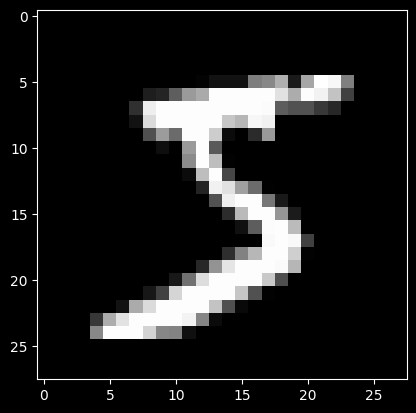

In [6]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape(28, 28),cmap = "gray")
pyplot.show()

In [7]:
import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n,c = x_train.shape
x_train, x_train.shape, y_train.min, y_train.max

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 torch.Size([50000, 784]),
 <function Tensor.min>,
 <function Tensor.max>)

In [8]:
import torch.nn.functional as F

loss_func = F.cross_entropy

def model(xb):
    return xb.mm(weights) + bias

In [9]:
bs = 64
xb = x_train[0:bs]
yb = y_train[0:bs]
weights = torch.randn([784,10], dtype = torch.float, requires_grad = True)
bs = 64
bias = torch.zeros(10,requires_grad = True)

print(loss_func(model(xb), yb).item())

16.9207706451416


In [10]:
from torch import nn

class Mnist_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784,128)
        self.hidden2 = nn.Linear(128,256)
        # self.hidden3 = nn.Linear(256,512)
        self.out = nn.Linear(256,10)
        self.dropout = nn.Dropout(0.5) #防止过拟合，随机去除一些拟合

    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = self.dropout(x)
        x = F.relu(self.hidden2(x))
        x = self.dropout(x)
        x = self.out(x)
        return x

In [11]:
net = Mnist_NN()
print(net)

Mnist_NN(
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [12]:
for name, parameter in net.named_parameters():
    print(name, parameter, parameter.size())

hidden1.weight Parameter containing:
tensor([[ 0.0192, -0.0195,  0.0338,  ..., -0.0304, -0.0230,  0.0042],
        [-0.0147,  0.0027,  0.0270,  ...,  0.0175,  0.0218, -0.0164],
        [-0.0276,  0.0023, -0.0253,  ...,  0.0152,  0.0049, -0.0298],
        ...,
        [ 0.0076, -0.0320, -0.0350,  ...,  0.0145,  0.0030, -0.0319],
        [ 0.0263,  0.0057, -0.0181,  ...,  0.0170,  0.0217, -0.0008],
        [-0.0296, -0.0171, -0.0106,  ..., -0.0108,  0.0113, -0.0116]],
       requires_grad=True) torch.Size([128, 784])
hidden1.bias Parameter containing:
tensor([-0.0204,  0.0261,  0.0094,  0.0056,  0.0183, -0.0054, -0.0061, -0.0148,
         0.0202,  0.0130, -0.0142, -0.0005,  0.0099, -0.0301, -0.0112,  0.0286,
        -0.0034, -0.0293,  0.0036,  0.0151, -0.0263,  0.0041,  0.0192, -0.0309,
         0.0037,  0.0348, -0.0059, -0.0075, -0.0083, -0.0244,  0.0086,  0.0082,
        -0.0322,  0.0134, -0.0170,  0.0044,  0.0229, -0.0172, -0.0194, -0.0219,
         0.0014,  0.0267,  0.0229, -0.0288, 

In [13]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train,y_train)
train_dl = DataLoader(train_ds, batch_size = bs, shuffle=True)

valid_ds = TensorDataset(x_valid,y_valid)
valid_dl = DataLoader(valid_ds, batch_size = bs*2)

In [14]:
def get_data(train_ds, valid_ds, bs):
    return(
        DataLoader(train_ds, batch_size=bs, shuffle=True),
        DataLoader(valid_ds, batch_size=bs*2)
    )

In [15]:
import numpy as np

def fit(steps, model, loss_fn, opt, train_dl, valid_dl):
    for step in range(steps):
        model.train()
        for xb, yb in train_dl:
            # 训练阶段：传opt，正常更新参数（这行是对的）
            loss_batch(model, loss_fn, xb, yb, opt)

        model.eval()
        with torch.no_grad():
            losses, nums = zip(
                # 核心修复：验证阶段删掉opt参数！只传4个参数
                *[loss_batch(model, loss_fn, xb, yb) for xb, yb in valid_dl]
            )
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        print('当前step:'+str(step),'验证集损失：'+str(val_loss))

In [16]:
a = [1,2,3]
b = [4,5,6]
zipped = zip(a,b)
print(list(zipped))
a2, b2 = zip(*zip(a,b))
print(a2)
print(b2)

[(1, 4), (2, 5), (3, 6)]
(1, 2, 3)
(4, 5, 6)


In [17]:
from torch import optim
def get_model():
    model = Mnist_NN()
    return model, optim.SGD(model.parameters(), lr = 0.001)

In [18]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    """
    计算单批次损失：
    - 训练阶段（opt≠None）：计算损失 + 反向传播 + 更新参数
    - 验证阶段（opt=None）：仅计算损失，不执行反向传播
    """
    pred = model(xb)
    loss = loss_func(pred, yb)

    # 只有训练阶段（opt存在）才执行反向传播！
    if opt is not None:
        loss.backward()  # 反向传播（训练专属）
        opt.step()       # 更新参数
        opt.zero_grad()  # 清空梯度

    return loss.item(), len(xb)

In [19]:
train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
model, opt = get_model()
fit(30,model,loss_func,opt, train_dl, valid_dl )

当前step:0 验证集损失：2.277934192276001
当前step:1 验证集损失：2.2483425090789795
当前step:2 验证集损失：2.2052496322631834
当前step:3 验证集损失：2.1388879802703857
当前step:4 验证集损失：2.0357141094207765
当前step:5 验证集损失：1.883039617538452
当前step:6 验证集损失：1.681212222290039
当前step:7 验证集损失：1.45931602973938
当前step:8 验证集损失：1.260388876914978
当前step:9 验证集损失：1.1031025072097778
当前step:10 验证集损失：0.9842651672363282
当前step:11 验证集损失：0.8934803033828735
当前step:12 验证集损失：0.8207877278327942
当前step:13 验证集损失：0.7620126818656922
当前step:14 验证集损失：0.7116350818634033
当前step:15 验证集损失：0.668371367931366
当前step:16 验证集损失：0.6325813735961914
当前step:17 验证集损失：0.6009169083595276
当前step:18 验证集损失：0.5727541537284851
当前step:19 验证集损失：0.5491699228286743
当前step:20 验证集损失：0.5273220242977142
当前step:21 验证集损失：0.5082512783050537
当前step:22 验证集损失：0.4912011185646057
当前step:23 验证集损失：0.47655033888816833
当前step:24 验证集损失：0.4621277064323425
当前step:25 验证集损失：0.4492749026298523
当前step:26 验证集损失：0.43828178572654725
当前step:27 验证集损失：0.4285696783542633
当前step:28 验证集损失：0.4189668917655945


In [20]:
correct = 0
total = 0
model.eval()
for xb, yb in valid_dl:
    outputs = model(xb)
    _, predicted = torch.max(outputs.data, 1)
    total += yb.size(0)
    correct += (predicted == yb).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' %(100* correct / total))

Accuracy of the network on the 10000 test images: 89 %
